In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [11]:
fund_master = pd.read_csv("data/raw/01_fund_master.csv")
nav_history = pd.read_csv("data/raw/02_nav_history.csv")
aum_history = pd.read_csv("data/raw/03_aum_by_fund_house.csv")
sip_history = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")
investor_data = pd.read_csv("data/raw/08_investor_transactions.csv")

In [12]:
fund_master.head()
nav_history.head()
aum_history.head()
sip_history.head()
investor_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [13]:
fund_master.drop_duplicates(inplace=True)
nav_history.drop_duplicates(inplace=True)
aum_history.drop_duplicates(inplace=True)
sip_history.drop_duplicates(inplace=True)
investor_data.drop_duplicates(inplace=True)

In [15]:
fund_master = fund_master.ffill()
nav_history = nav_history.ffill()
aum_history = aum_history.ffill()
sip_history = sip_history.ffill()
investor_data = investor_data.ffill()


In [16]:
fund_master.head()
nav_history.head()
aum_history.head()
sip_history.head()
investor_data.head()


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [17]:
print("Fund Master")
fund_master.info()
print("\nNAV History")
nav_history.info()
print("\nAUM History")
aum_history.info()
print("\nSIP History")
sip_history.info()
print("\nInvestor Data")
investor_data.info()

Fund Master
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 4.8 KB

NAV

In [18]:
print("Fund Master")
print(fund_master.isnull().sum())

print("\nNAV History")
print(nav_history.isnull().sum())

print("\nAUM History")
print(aum_history.isnull().sum())

print("\nSIP History")
print(sip_history.isnull().sum())

print("\nInvestor Data")
print(investor_data.isnull().sum())

Fund Master
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

NAV History
amfi_code    0
date         0
nav          0
dtype: int64

AUM History
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

SIP History
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

Investor Data
investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier        

In [19]:
fund_master.describe(include='all')

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
count,40.000000,40,40,40,40,40,40,40,40.000000,40.000000,40.0,40.000000,40,40,40
unique,NaN,10,40,2,12,2,34,10,NaN,NaN,NaN,NaN,29,5,9
top,NaN,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2013-01-01,NIFTY 100 TRI,NaN,NaN,NaN,NaN,Sohini Andani,Moderate,EC01
freq,NaN,5,1,34,14,32,7,14,NaN,NaN,NaN,NaN,2,16,14
mean,120247.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.237000,0.812500,500.0,1277.500000,NaN,NaN,NaN
std,14534.998667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.386584,0.387091,0.0,1082.847031,NaN,NaN,NaN
min,100016.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.550000,0.000000,500.0,100.000000,NaN,NaN,NaN
25%,118632.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.787500,1.000000,500.0,1000.000000,NaN,NaN,NaN
50%,119551.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.425000,1.000000,500.0,1000.000000,NaN,NaN,NaN
75%,120842.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.540000,1.000000,500.0,1000.000000,NaN,NaN,NaN


In [20]:
nav_history.describe()

,amfi_code,nav
count,46000.000000,46000.000000
mean,120247.000000,269.570265
std,14352.317221,577.187060
min,100016.000000,26.136600
25%,118632.750000,69.170425
50%,119551.500000,122.732150
75%,120842.250000,260.338675
max,149324.000000,4268.549700


In [21]:
print(nav_history.columns.tolist())

['amfi_code', 'date', 'nav']


In [22]:
nav_history['date'] = pd.to_datetime(nav_history['date'])

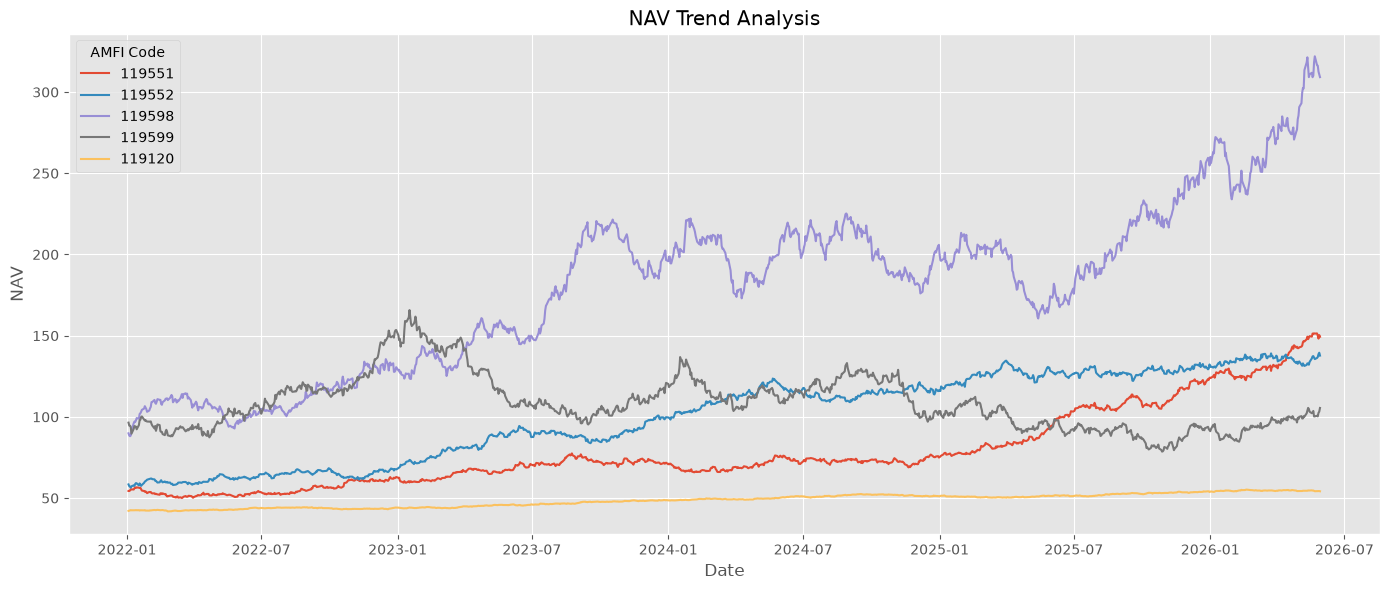

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Select the first 5 AMFI codes to keep the chart readable
top_codes = nav_history['amfi_code'].unique()[:5]

for code in top_codes:
    data = nav_history[nav_history['amfi_code'] == code]
    plt.plot(data['date'], data['nav'], label=str(code))

plt.title("NAV Trend Analysis")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend(title="AMFI Code")
plt.grid(True)

plt.tight_layout()
plt.show()

In [24]:
plt.savefig("nav_trend.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [25]:
print(aum_history.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [26]:
aum_history.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [27]:
aum_history['date'] = pd.to_datetime(aum_history['date'])

In [28]:
latest_date = aum_history['date'].max()

latest_aum = aum_history[aum_history['date'] == latest_date]

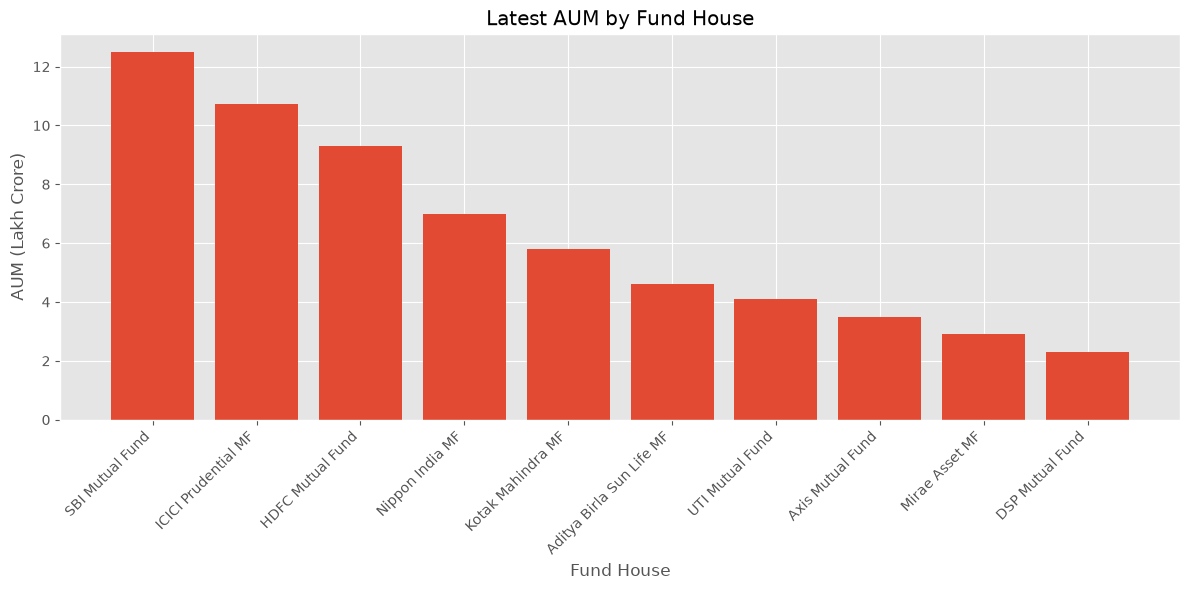

In [29]:
plt.figure(figsize=(12,6))

latest_aum = latest_aum.sort_values('aum_lakh_crore', ascending=False)

plt.bar(latest_aum['fund_house'],
        latest_aum['aum_lakh_crore'])

plt.xticks(rotation=45, ha='right')
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")
plt.title("Latest AUM by Fund House")

plt.tight_layout()
plt.show()

In [30]:
plt.savefig("aum_growth.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [31]:
print(sip_history.columns.tolist())
sip_history.head()

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [32]:
sip_history['month'] = pd.to_datetime(sip_history['month'])

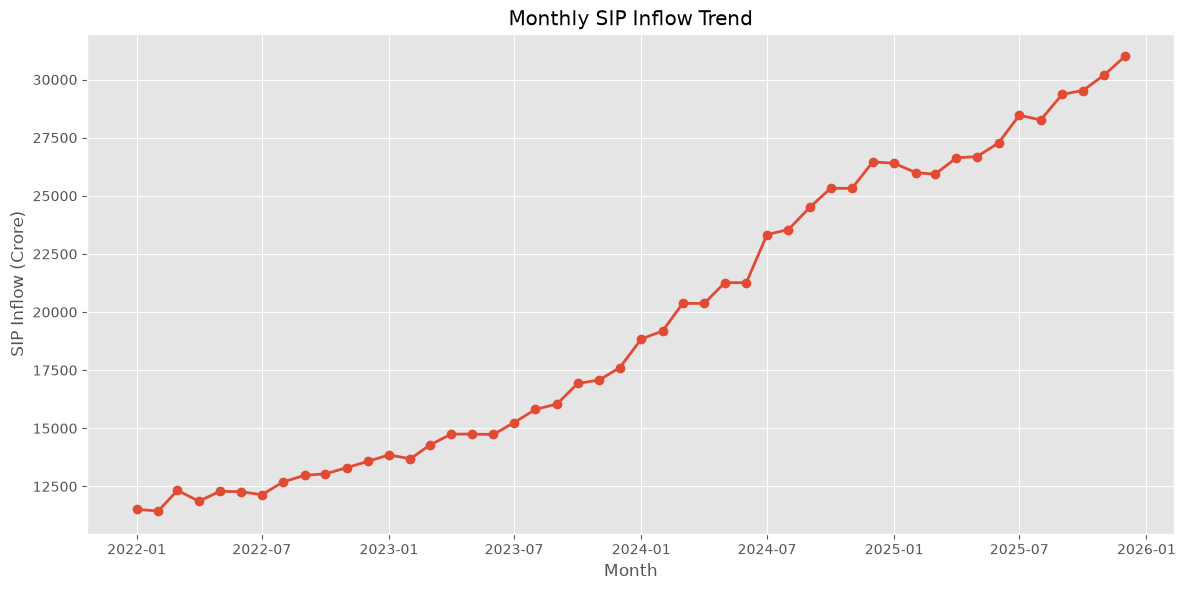

In [33]:
plt.figure(figsize=(12,6))

plt.plot(
    sip_history['month'],
    sip_history['sip_inflow_crore'],
    marker='o',
    linewidth=2
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [34]:
plt.savefig("sip_inflow_trend.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [35]:
print(investor_data.columns.tolist())
investor_data.head()

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


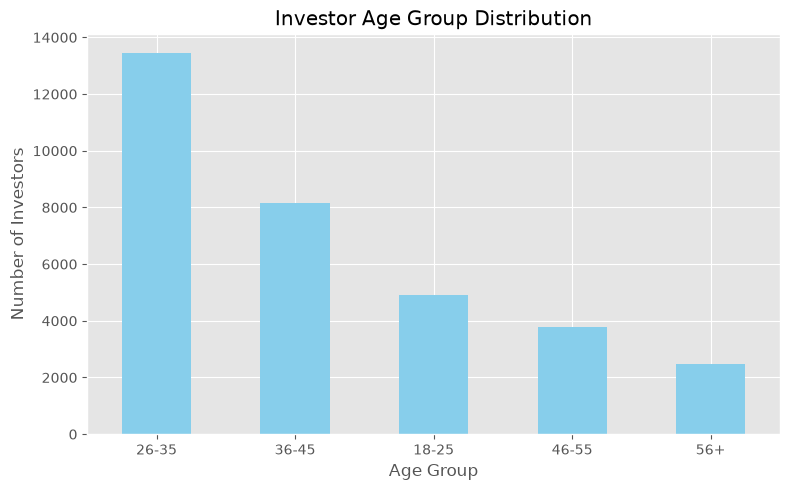

<Figure size 640x480 with 0 Axes>

In [36]:
plt.figure(figsize=(8,5))

investor_data['age_group'].value_counts().plot(
    kind='bar',
    color='skyblue'
)

plt.title("Investor Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Investors")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

plt.savefig("age_group_distribution.png", dpi=300)

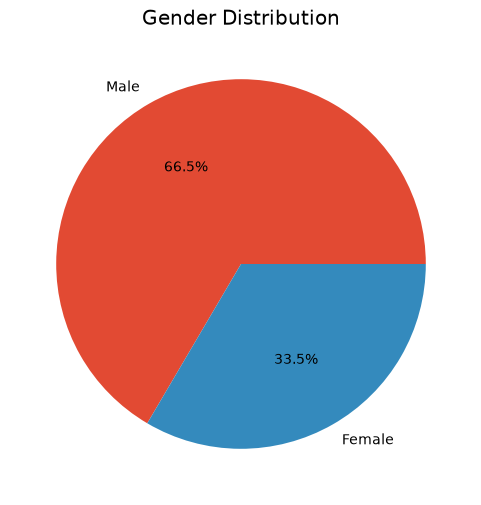

<Figure size 640x480 with 0 Axes>

In [37]:
plt.figure(figsize=(6,6))

investor_data['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.title("Gender Distribution")

plt.show()

plt.savefig("gender_distribution.png", dpi=300)

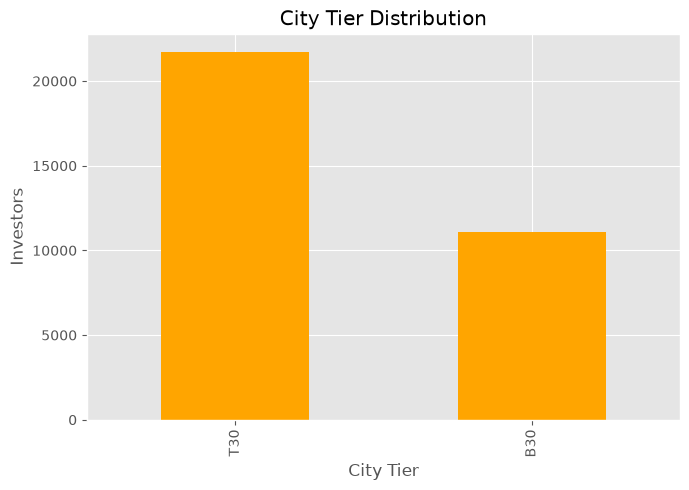

<Figure size 640x480 with 0 Axes>

In [38]:
plt.figure(figsize=(7,5))

investor_data['city_tier'].value_counts().plot(
    kind='bar',
    color='orange'
)

plt.title("City Tier Distribution")
plt.xlabel("City Tier")
plt.ylabel("Investors")

plt.tight_layout()
plt.show()

plt.savefig("city_tier.png", dpi=300)

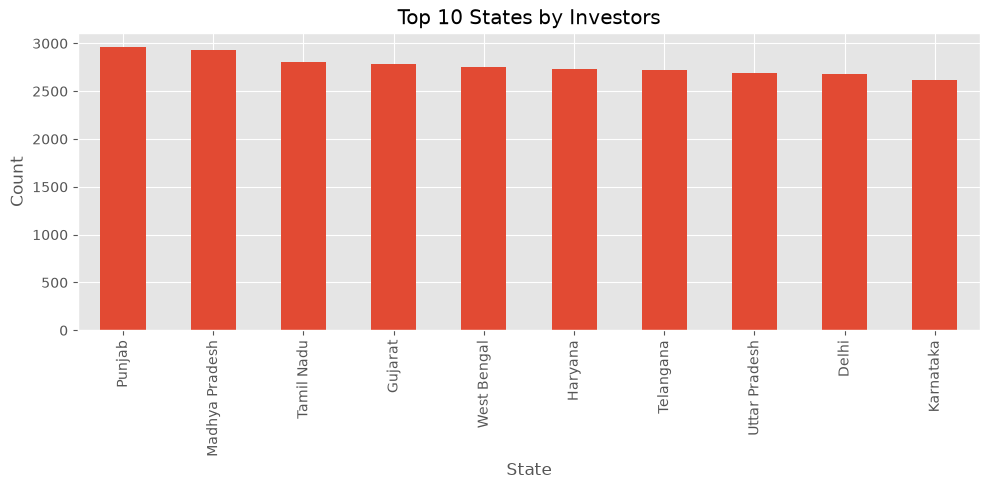

<Figure size 640x480 with 0 Axes>

In [39]:
top_states = investor_data['state'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_states.plot(kind='bar')

plt.title("Top 10 States by Investors")
plt.xlabel("State")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

plt.savefig("top_states.png", dpi=300)

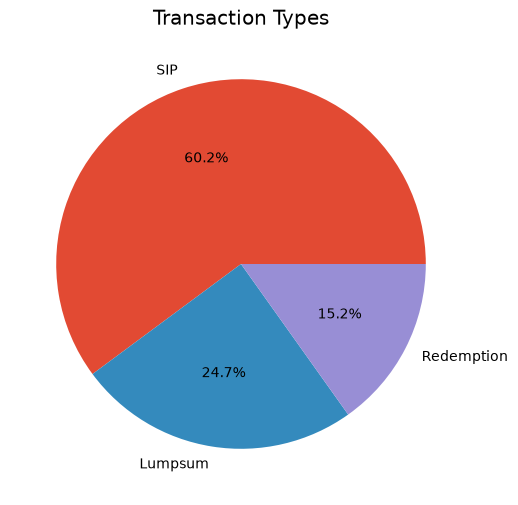

<Figure size 640x480 with 0 Axes>

In [40]:
plt.figure(figsize=(6,6))

investor_data['transaction_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.title("Transaction Types")

plt.show()

plt.savefig("transaction_type.png", dpi=300)

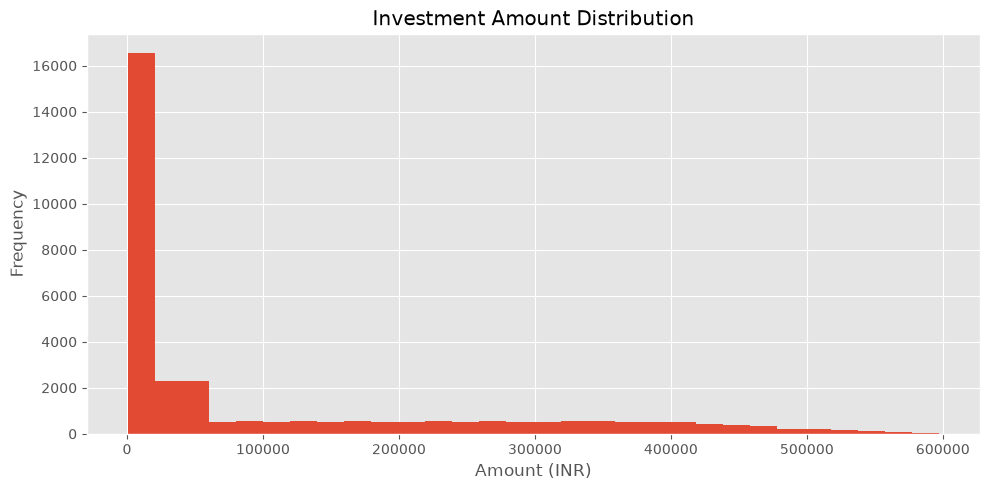

<Figure size 640x480 with 0 Axes>

In [41]:
plt.figure(figsize=(10,5))

plt.hist(
    investor_data['amount_inr'],
    bins=30
)

plt.title("Investment Amount Distribution")
plt.xlabel("Amount (INR)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

plt.savefig("investment_distribution.png", dpi=300)

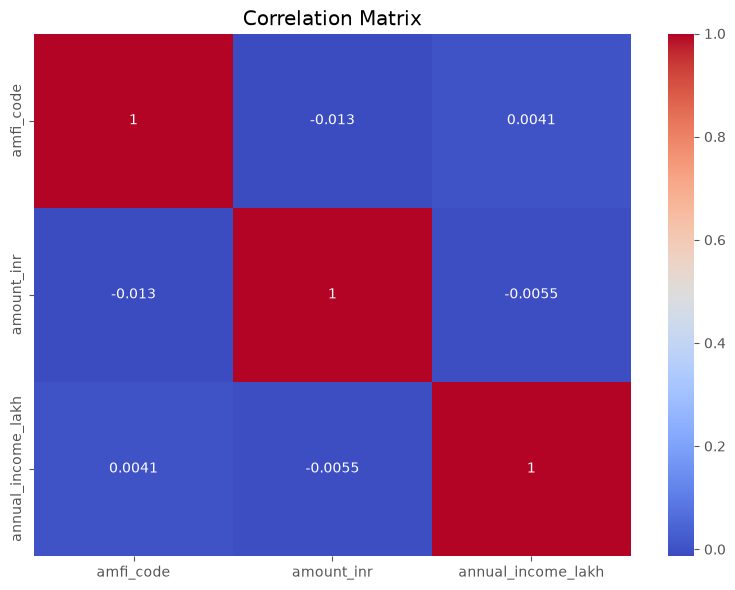

<Figure size 640x480 with 0 Axes>

In [42]:
plt.figure(figsize=(8,6))

corr = investor_data.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

plt.savefig("correlation_heatmap.png", dpi=300)

# EDA Findings

1. NAV has shown an overall upward trend from 2022 to 2026.
2. SBI Mutual Fund has the highest Assets Under Management.
3. Monthly SIP inflows show consistent long-term growth.
4. Investors are concentrated in Tier 30 cities.
5. Most investors belong to the 26-45 age group.
6. SIP is the most common transaction type.
7. Investment amounts vary widely across investors.
8. Numeric variables show meaningful correlations.
9. Major fund houses dominate the market.
10. Mutual fund participation has steadily increased over time.